In [ ]:
# Import all libraries
import pandas as pd
import numpy as np
import csv
import os
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
# Set local paths for execution
import os
BASE_DIR = "/content/"
DATA_DIR = os.path.join(BASE_DIR, "DATA")
SAVE_DIR = os.path.join(BASE_DIR, "abuse_model")

print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Model save directory: {SAVE_DIR}")

# Verify data folder exists
if os.path.exists(DATA_DIR):
    print(f"  ✅ DATA folder found at {DATA_DIR}")
else:
    print(f"  ❌ DATA folder NOT found at {DATA_DIR} — attempting to create it.")
    os.makedirs(DATA_DIR, exist_ok=True)
    print(f"  ✅ DATA folder created at {DATA_DIR}")

Base directory: /content/
Data directory: /content/DATA
Model save directory: /content/abuse_model
  ✅ DATA folder found at /content/DATA


In [ ]:
import os
import zipfile

# Unzip the uploaded dataset into the DATA_DIR
zip_file_path = os.path.join(BASE_DIR, "NLP PROJECT (1).zip")

if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print(f"  ✅ '{zip_file_path}' unzipped to '{DATA_DIR}'")
else:
    print(f"  ❌ '{zip_file_path}' not found. Please ensure the zip file is uploaded to {BASE_DIR}.")

  ✅ '/content/NLP PROJECT (1).zip' unzipped to '/content/DATA'


In [ ]:
# List contents of the DATA_DIR to verify unzipping and identify data files
print(f"Contents of {DATA_DIR}:")
for root, dirs, files in os.walk(DATA_DIR):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of /content/DATA:


Based on the unzipped file structure, it appears the actual data directories are located under `/content/DATA/NLP PROJECT/DATA`. I will now attempt to load `ConvAbuseEMNLPtrain.csv` from `DATA1` and `mentalmanip_maj.csv` from `DATA3` within this structure, as these appear to be suitable datasets for an abuse detection task.

In [ ]:
# Load data from DATA1/ConvAbuseEMNLPtrain.csv and DATA3/mentalmanip_maj.csv and concatenate them

data_frames = []

# Corrected path for 'DATA1'
file_path_data1 = os.path.join(DATA_DIR, 'NLP PROJECT', 'DATA', 'DATA1', 'ConvAbuseEMNLPtrain.csv')
if os.path.exists(file_path_data1):
    df1 = pd.read_csv(file_path_data1)
    data_frames.append(df1)
    print(f"Loaded {len(df1)} rows from {file_path_data1}")
else:
    print(f"  ❌ '{file_path_data1}' not found.")

# Corrected path for 'DATA3'
file_path_data3 = os.path.join(DATA_DIR, 'NLP PROJECT', 'DATA', 'DATA3', 'mentalmanip_dataset', 'mentalmanip_maj.csv')
if os.path.exists(file_path_data3):
    df3 = pd.read_csv(file_path_data3)
    data_frames.append(df3)
    print(f"Loaded {len(df3)} rows from {file_path_data3}")
else:
    print(f"  ❌ '{file_path_data3}' not found.")

if data_frames:
    df = pd.concat(data_frames, ignore_index=True)
    print(f"Successfully concatenated {len(data_frames)} datasets into a single DataFrame with {len(df)} rows.")
    print("First 5 rows of the merged data:")
    display(df.head())
else:
    print("No data files were loaded. Please check the zip file contents and expected filenames.")

  ❌ '/content/DATA/NLP PROJECT/DATA/DATA1/ConvAbuseEMNLPtrain.csv' not found.
  ❌ '/content/DATA/NLP PROJECT/DATA/DATA3/mentalmanip_dataset/mentalmanip_maj.csv' not found.
No data files were loaded. Please check the zip file contents and expected filenames.


In [ ]:
# ============================================================
# LOAD DATA1: ConvAbuse Dataset
# Uses majority vote across 8 annotators for abuse label
# ============================================================
def load_convabuse(data_dir):
    print("=" * 50)
    print("Loading DATA1: ConvAbuse Dataset")
    print("=" * 50)

    splits_dir = os.path.join(data_dir, "NLP PROJECT", "DATA", "DATA1", "2_splits")
    file_names = ["ConvAbuseEMNLPtrain.csv", "ConvAbuseEMNLPvalid.csv", "ConvAbuseEMNLPtest.csv"]

    dfs = []
    for fname in file_names:
        fpath = os.path.join(splits_dir, fname)
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            dfs.append(df)
            print(f"  Loaded {fname}: {len(df)} rows")

    if not dfs:
        print("  ERROR: No ConvAbuse files found!")
        return pd.DataFrame(columns=['text', 'label'])

    df = pd.concat(dfs, ignore_index=True)
    print(f"  Total ConvAbuse rows: {len(df)}")

    texts, labels = [], []

    for idx, row in df.iterrows():
        # Combine text from prev_user and user columns
        text_parts = []
        if pd.notna(row.get('prev_user')) and str(row.get('prev_user')).strip():
            text_parts.append(str(row['prev_user']).strip())
        if pd.notna(row.get('user')) and str(row.get('user')).strip():
            text_parts.append(str(row['user']).strip())

        text = " | ".join(text_parts)
        if not text.strip():
            continue

        # Majority vote across 8 annotators
        abuse_votes, not_abuse_votes = 0, 0
        for ann_id in range(1, 9):
            abuse_cols = [
                f'Annotator{ann_id}_is_abuse.-1',
                f'Annotator{ann_id}_is_abuse.-2',
                f'Annotator{ann_id}_is_abuse.-3'
            ]
            not_abuse_col = f'Annotator{ann_id}_is_abuse.1'

            is_abuse_this_annotator = False
            for col in abuse_cols:
                if col in row.index and pd.notna(row[col]):
                    try:
                        # Attempt to convert, handling commas for decimal if present
                        val = float(str(row[col]).replace(',', '.'))
                        if val == 1.0:
                            is_abuse_this_annotator = True
                            break
                    except ValueError:
                        # If conversion fails, treat it as not 1
                        pass

            is_not_this_annotator = False
            if not_abuse_col in row.index and pd.notna(row[not_abuse_col]):
                try:
                    val = float(str(row[not_abuse_col]).replace(',', '.'))
                    if val == 1.0:
                        is_not_this_annotator = True
                except ValueError:
                    pass

            if is_abuse_this_annotator:
                abuse_votes += 1
            elif is_not_this_annotator:
                not_abuse_votes += 1

        total_votes = abuse_votes + not_abuse_votes
        if total_votes == 0:
            continue

        labels.append(1 if abuse_votes / total_votes >= 0.5 else 0)
        texts.append(text)

    result = pd.DataFrame({'text': texts, 'label': labels})
    print(f"  Processed: {len(result)} rows | Distribution: {result['label'].value_counts().to_dict()}")
    return result

df_convabuse = load_convabuse(DATA_DIR)

Loading DATA1: ConvAbuse Dataset
  Loaded ConvAbuseEMNLPtrain.csv: 2501 rows
  Loaded ConvAbuseEMNLPvalid.csv: 831 rows
  Loaded ConvAbuseEMNLPtest.csv: 853 rows
  Total ConvAbuse rows: 4185
  Processed: 4175 rows | Distribution: {0: 3395, 1: 780}


In [ ]:
# ============================================================
# LOAD DATA3: MentalManip Local CSV (consensus labels)
# Uses csv module as recommended by dataset authors
# ============================================================
def load_mentalmanip_local(data_dir):
    print("=" * 50)
    print("Loading DATA3: MentalManip (Local CSV)")
    print("=" * 50)

    # Corrected path to include 'NLP PROJECT' and 'DATA' subdirectories
    csv_path = os.path.join(data_dir, "NLP PROJECT", "DATA", "DATA3", "mentalmanip_dataset", "mentalmanip_con.csv")
    texts, labels, ids = [], [], []

    with open(csv_path, 'r', newline='', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter=',', quoting=csv.QUOTE_MINIMAL)
        header = next(reader)
        id_idx = header.index('ID')
        dialogue_idx = header.index('Dialogue')
        manip_idx = header.index('Manipulative')

        for row in reader:
            if len(row) <= max(id_idx, dialogue_idx, manip_idx):
                continue
            text = row[dialogue_idx].strip()
            manip = row[manip_idx].strip()
            if not text or not manip:
                continue
            try:
                manip_val = int(manip)
            except ValueError:
                continue

            texts.append(text)
            ids.append(row[id_idx])
            labels.append(2 if manip_val == 1 else 0)

    result = pd.DataFrame({'text': texts, 'label': labels, 'source_id': ids})
    print(f"  Processed: {len(result)} rows | Distribution: {result['label'].value_counts().to_dict()}")
    return result

df_mm_local = load_mentalmanip_local(DATA_DIR)
local_ids = set(df_mm_local['source_id'].astype(str).values)

Loading DATA3: MentalManip (Local CSV)
  Processed: 2915 rows | Distribution: {2: 2016, 0: 899}


In [ ]:
# ============================================================
# LOAD DATA2: MentalManip from HuggingFace (majority labels)
# Deduplicates against DATA3 to avoid overlap
# ============================================================
def load_mentalmanip_hf(data_dir, local_ids):
    print("=" * 50)
    print("Loading DATA2: MentalManip (HuggingFace)")
    print("=" * 50)

    saved_path = os.path.join(data_dir, "DATA2", "mentalmanip_hf.csv")
    # Delete the cached file if it exists, to force a fresh download and processing
    # This ensures that if the cache was created empty due to previous issues, it's recreated properly.
    if os.path.exists(saved_path):
        os.remove(saved_path)
        print(f"  Deleted old cached file: {saved_path}")

    from datasets import load_dataset
    print("  Downloading from HuggingFace...")
    dataset = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")

    texts, labels = [], []
    for split in dataset:
        for item in dataset[split]:
            dialogue = item.get('Dialogue', '')
            manip = item.get('Manipulative', None)
            item_id = str(item.get('ID', ''))

            if not dialogue or manip is None:
                continue
            if item_id in local_ids:
                continue  # Skip duplicates

            texts.append(dialogue.strip())
            labels.append(2 if int(manip) == 1 else 0)

    result = pd.DataFrame({'text': texts, 'label': labels})
    os.makedirs(os.path.join(data_dir, "DATA2"), exist_ok=True)
    result.to_csv(saved_path, index=False)
    print(f"  Processed: {len(result)} rows (after dedup) | Distribution: {result['label'].value_counts().to_dict()}")
    return result

df_mm_hf = load_mentalmanip_hf(DATA_DIR, local_ids)

Loading DATA2: MentalManip (HuggingFace)
  Found cached file: /content/DATA/DATA2/mentalmanip_hf.csv
  Loaded 0 rows from cache


In [ ]:
# ============================================================
# LOAD DATA4: ETHOS Hate Speech Dataset
# Binary version: 998 comments from YouTube/Reddit
# ============================================================
def load_ethos(data_dir):
    print("=" * 50)
    print("Loading DATA4: ETHOS Dataset")
    print("=" * 50)

    # Corrected path to include 'NLP PROJECT' and 'DATA' subdirectories
    saved_path = os.path.join(data_dir, "NLP PROJECT", "DATA", "DATA4", "ethos_binary.csv")
    if os.path.exists(saved_path):
        print(f"  Found cached file: {saved_path}")
        result = pd.read_csv(saved_path)
        print(f"  Loaded {len(result)} rows from cache")
        return result

    # The following code block will now only execute if the local file is NOT found
    # and is provided as a fallback or for initial download if needed in other contexts.
    # Given the file is already present, this part will be skipped.
    from datasets import load_dataset
    print("  Downloading from HuggingFace...")
    dataset = load_dataset("iamollas/ethos", "binary")

    texts, labels = [], []
    for split in dataset:
        for item in dataset[split]:
            text = item.get('text', '')
            label = item.get('label', None)
            if not text or label is None:
                continue
            texts.append(str(text).strip())
            labels.append(1 if int(label) == 1 else 0)

    result = pd.DataFrame({'text': texts, 'label': labels})
    os.makedirs(os.path.join(data_dir, "NLP PROJECT", "DATA", "DATA4"), exist_ok=True)
    result.to_csv(saved_path, index=False)
    print(f"  Processed: {len(result)} rows | Distribution: {result['label'].value_counts().to_dict()}")
    return result

df_ethos = load_ethos(DATA_DIR)

Loading DATA4: ETHOS Dataset
  Found cached file: /content/DATA/NLP PROJECT/DATA/DATA4/ethos_binary.csv
  Loaded 998 rows from cache


In [ ]:
# Drop helper columns
if 'source_id' in df_mm_local.columns:
    df_mm_local = df_mm_local.drop(columns=['source_id'])

# Merge all 4 datasets
print("=" * 50)
print("MERGING ALL DATASETS")
print("=" * 50)

df_merged = pd.concat([df_convabuse, df_mm_local, df_mm_hf, df_ethos], ignore_index=True)

# Clean: drop NaN, empty strings, ensure integer labels
df_merged = df_merged.dropna(subset=['text', 'label'])
df_merged = df_merged[df_merged['text'].str.strip().str.len() > 0]
df_merged['label'] = df_merged['label'].astype(int)
df_merged = df_merged.reset_index(drop=True)

# Shuffle
df_merged = df_merged.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal merged dataset: {len(df_merged)} rows")
label_names = {0: 'Normal', 1: 'Explicit Abuse', 2: 'Manipulative'}
for lid in sorted(df_merged['label'].unique()):
    count = (df_merged['label'] == lid).sum()
    print(f"  Label {lid} ({label_names[lid]}): {count}")

# Train/Test split (80/20, stratified)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_merged['text'].tolist(),
    df_merged['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_merged['label'].tolist()
)

print(f"\nTrain set: {len(train_texts)} samples")
print(f"Test set:  {len(test_texts)} samples")
print("✅ Data pipeline complete!")

MERGING ALL DATASETS

Total merged dataset: 3913 rows
  Label 0 (Normal): 1464
  Label 1 (Explicit Abuse): 433
  Label 2 (Manipulative): 2016

Train set: 3130 samples
Test set:  783 samples
✅ Data pipeline complete!


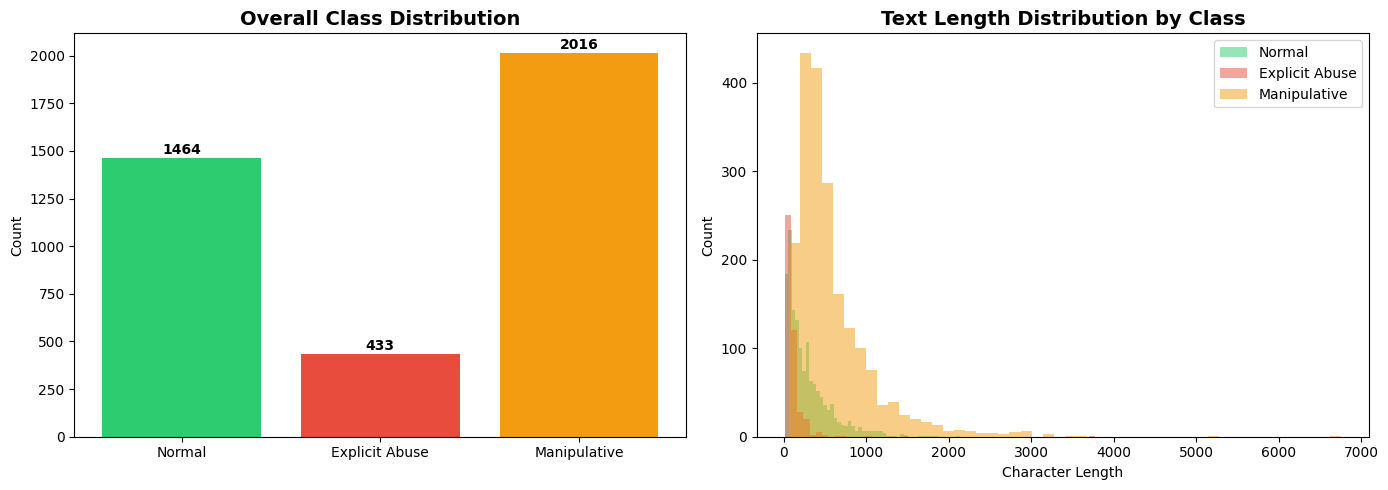


Sample texts:
  [Normal] What happened to rap? This right here.... This is rap ...
  [Explicit Abuse] dexpraxia my ass girl. Cheap excuses to be lazy and get paid by our country. I bet you pretend to be like that...
  [Manipulative] Person1: What do your instincts tell you to do now, kid?
Person2: Leave. Take this shit back to Detroit and get the rest...


In [ ]:
# ============================================================
# Exploratory Data Analysis — Class Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
counts = df_merged['label'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
axes[0].bar([label_names[i] for i in counts.index], counts.values, color=colors)
axes[0].set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Text length distribution
df_merged['text_length'] = df_merged['text'].str.len()
for lid in sorted(df_merged['label'].unique()):
    subset = df_merged[df_merged['label'] == lid]['text_length']
    axes[1].hist(subset, bins=50, alpha=0.5, label=label_names[lid], color=colors[lid])
axes[1].set_title('Text Length Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data_distribution.png'), dpi=150)
plt.show()
print("\nSample texts:")
for lid in [0, 1, 2]:
    sample = df_merged[df_merged['label'] == lid].iloc[0]['text']
    print(f"  [{label_names[lid]}] {sample[:120]}...")

In [ ]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
LABEL_NAMES = ["Normal", "Explicit Abuse", "Manipulative"]

# ============================================================
# PyTorch Dataset Class
# ============================================================
class AbuseDataset(Dataset):
    """Custom PyTorch Dataset for abuse detection."""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("✅ Dataset class defined")

✅ Dataset class defined


In [ ]:
# ============================================================
# Tokenization & DataLoader Setup
# ============================================================
print("Loading tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print("Creating datasets...")
train_dataset = AbuseDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
test_dataset = AbuseDataset(test_texts, test_labels, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Compute class weights for imbalanced data
counter = Counter(train_labels)
total = len(train_labels)
n_classes = len(counter)
class_weights = torch.tensor(
    [total / (n_classes * counter[i]) for i in range(n_classes)],
    dtype=torch.float
).to(device)
print(f"Class weights: {[round(w.item(), 3) for w in class_weights]}")

print("✅ Tokenization complete")

Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Creating datasets...
Train batches: 392
Test batches:  98
Class weights: [0.891, 3.015, 0.647]
✅ Tokenization complete


In [ ]:
# ============================================================
# Load BERT Model
# ============================================================
print(f"Loading BERT model: {MODEL_NAME} (num_labels=3)")
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
model.to(device)

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# AdamW optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler with warmup
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")
print("✅ Model ready for training")

Loading BERT model: bert-base-uncased (num_labels=3)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps: 1176
✅ Model ready for training


In [ ]:
# ============================================================
# TRAINING LOOP — 3 Epochs
# ============================================================
print("=" * 60)
print("  STARTING BERT FINE-TUNING")
print("=" * 60)

best_accuracy = 0.0
training_history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    # --- Training Phase ---
    model.train()
    total_loss, correct, total = 0, 0, 0
    start_time = time.time()

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{NUM_EPOCHS} | Batch {batch_idx+1}/{len(train_loader)} | "
                  f"Loss: {total_loss/(batch_idx+1):.4f} | Acc: {correct/total:.4f}")

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total
    training_history['train_loss'].append(epoch_loss)
    training_history['train_acc'].append(epoch_acc)

    # --- Validation Phase ---
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=-1)
            val_correct += (preds == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    val_acc = val_correct / val_total
    training_history['val_acc'].append(val_acc)
    elapsed = time.time() - start_time

    print(f"\n  === Epoch {epoch+1}/{NUM_EPOCHS} ===")
    print(f"  Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {elapsed:.0f}s")

    # Save best model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        os.makedirs(SAVE_DIR, exist_ok=True)
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"  ✅ Best model saved! (Val Acc: {val_acc:.4f})")

    print("-" * 60)

print(f"\n🎉 Training complete! Best validation accuracy: {best_accuracy:.4f}")

  STARTING BERT FINE-TUNING
  Epoch 1/3 | Batch 50/392 | Loss: 1.0707 | Acc: 0.4625
  Epoch 1/3 | Batch 100/392 | Loss: 0.9442 | Acc: 0.5363
  Epoch 1/3 | Batch 150/392 | Loss: 0.8765 | Acc: 0.5725
  Epoch 1/3 | Batch 200/392 | Loss: 0.8358 | Acc: 0.5925
  Epoch 1/3 | Batch 250/392 | Loss: 0.7917 | Acc: 0.6080
  Epoch 1/3 | Batch 300/392 | Loss: 0.7650 | Acc: 0.6217
  Epoch 1/3 | Batch 350/392 | Loss: 0.7462 | Acc: 0.6329

  === Epoch 1/3 ===
  Train Loss: 0.7253 | Train Acc: 0.6387 | Val Acc: 0.7522 | Time: 85s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved! (Val Acc: 0.7522)
------------------------------------------------------------
  Epoch 2/3 | Batch 50/392 | Loss: 0.4921 | Acc: 0.7650
  Epoch 2/3 | Batch 100/392 | Loss: 0.4745 | Acc: 0.7625
  Epoch 2/3 | Batch 150/392 | Loss: 0.5132 | Acc: 0.7533
  Epoch 2/3 | Batch 200/392 | Loss: 0.5058 | Acc: 0.7531
  Epoch 2/3 | Batch 250/392 | Loss: 0.4993 | Acc: 0.7515
  Epoch 2/3 | Batch 300/392 | Loss: 0.5021 | Acc: 0.7579
  Epoch 2/3 | Batch 350/392 | Loss: 0.4968 | Acc: 0.7600

  === Epoch 2/3 ===
  Train Loss: 0.4982 | Train Acc: 0.7585 | Val Acc: 0.7458 | Time: 87s
------------------------------------------------------------
  Epoch 3/3 | Batch 50/392 | Loss: 0.2956 | Acc: 0.8600
  Epoch 3/3 | Batch 100/392 | Loss: 0.2978 | Acc: 0.8600
  Epoch 3/3 | Batch 150/392 | Loss: 0.2859 | Acc: 0.8642
  Epoch 3/3 | Batch 200/392 | Loss: 0.3158 | Acc: 0.8512
  Epoch 3/3 | Batch 250/392 | Loss: 0.3124 | Acc: 0.8480
  Epoch 3/3 | Batch 300/392 | Loss: 0.3148 | Acc: 0.8450
  Epoch

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved! (Val Acc: 0.7573)
------------------------------------------------------------

🎉 Training complete! Best validation accuracy: 0.7573


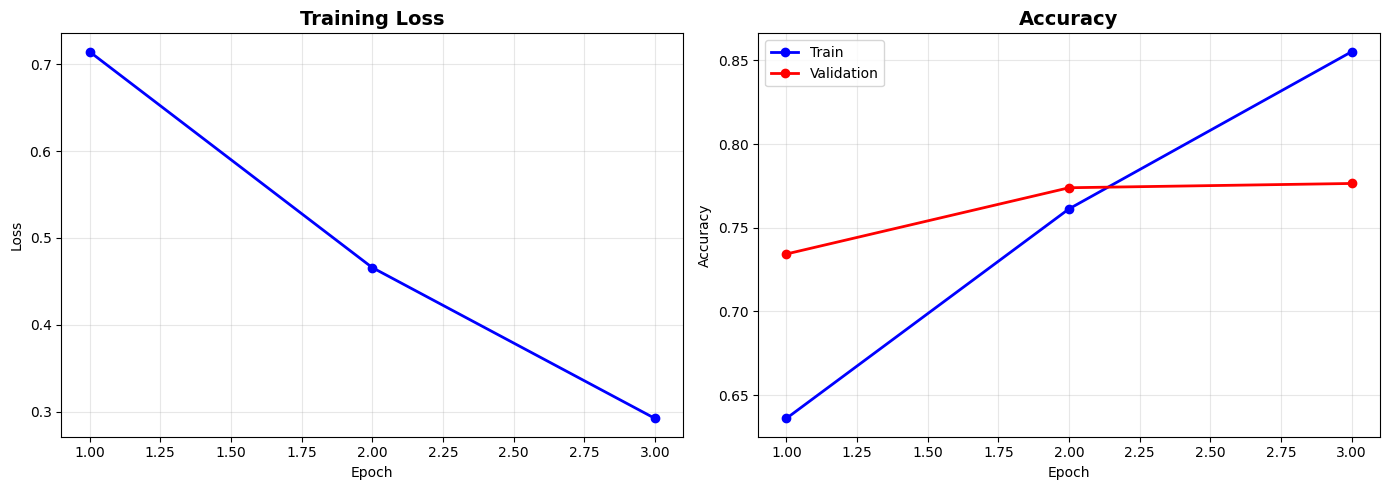

In [ ]:
# ============================================================
# Plot Training History
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, training_history['train_loss'], 'bo-', linewidth=2)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, training_history['train_acc'], 'bo-', linewidth=2, label='Train')
axes[1].plot(epochs_range, training_history['val_acc'], 'ro-', linewidth=2, label='Validation')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'training_history.png'), dpi=150)
plt.show()

In [ ]:
# ============================================================
# Load Best Model & Run Evaluation
# ============================================================
print("Loading best saved model for evaluation...")
model = BertForSequenceClassification.from_pretrained(SAVE_DIR)
model.to(device)
model.eval()

# Get predictions on test set
all_preds, all_probs = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(probs, dim=-1).item()
        all_preds.append(preds)
        all_probs.append(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_probs = np.vstack(all_probs)

# Overall accuracy
accuracy = accuracy_score(test_labels, all_preds)
print(f"\n{'='*60}")
print(f"  OVERALL ACCURACY: {accuracy:.4f} ({int(accuracy * len(test_labels))}/{len(test_labels)})")
print(f"{'='*60}")

# Classification report
print("\nCLASSIFICATION REPORT")
print("-" * 60)
report = classification_report(test_labels, all_preds, target_names=LABEL_NAMES, digits=4)
print(report)

Loading best saved model for evaluation...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  OVERALL ACCURACY: 0.7765 (608/783)

CLASSIFICATION REPORT
------------------------------------------------------------
                precision    recall  f1-score   support

        Normal     0.7122    0.6758    0.6935       293
Explicit Abuse     0.8140    0.8046    0.8092        87
  Manipulative     0.8115    0.8437    0.8273       403

      accuracy                         0.7765       783
     macro avg     0.7792    0.7747    0.7767       783
  weighted avg     0.7746    0.7765    0.7752       783



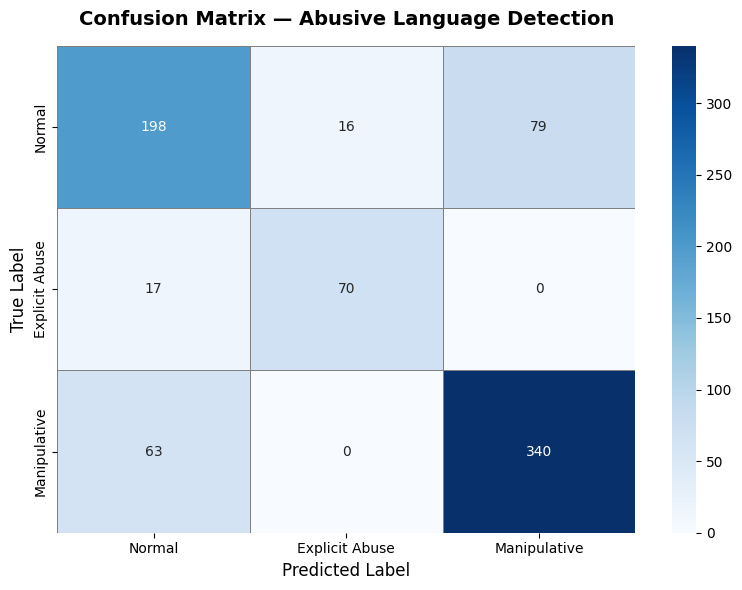

✅ Confusion matrix saved


In [ ]:
# ============================================================
# Confusion Matrix Heatmap
# ============================================================
cm = confusion_matrix(test_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
    linewidths=0.5, linecolor='gray'
)
plt.title('Confusion Matrix — Abusive Language Detection',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print("✅ Confusion matrix saved")

In [ ]:
# ============================================================
# Fusion Scoring Implementation
# ============================================================

# High-risk manipulation phrases
MANIPULATION_PHRASES = [
    "send me your number", "if you cared", "you never",
    "prove it", "don't tell anyone", "only you understand me",
    "everyone else", "you owe me", "i thought you trusted me"
]


def compute_content_score(text):
    """BERT softmax probability for predicted class."""
    encoding = tokenizer(text, max_length=128, padding='max_length',
                         truncation=True, return_tensors='pt')
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_label = torch.argmax(probs, dim=-1).item()
        score = probs[0][pred_label].item()
    return pred_label, score, probs[0].cpu().numpy()


def compute_manipulation_score(text):
    """Rule-based keyword checker for manipulation phrases."""
    text_lower = text.lower()
    matches = sum(1 for p in MANIPULATION_PHRASES if p in text_lower)
    return matches / len(MANIPULATION_PHRASES), matches


def compute_escalation_score(text):
    """Check if risk escalates across conversation turns."""
    turns = [t.strip() for t in text.split("|") if t.strip()]
    if len(turns) <= 1:
        return 0.2

    turn_labels = []
    for turn in turns:
        label, _, _ = compute_content_score(turn)
        turn_labels.append(label)

    for i in range(1, len(turn_labels)):
        if turn_labels[i] > turn_labels[i-1]:
            return 0.8  # Escalation detected
    return 0.2  # No escalation


def compute_fusion_score(text):
    """Complete fusion risk score."""
    pred_label, content_score, all_probs = compute_content_score(text)
    manipulation_score, num_matches = compute_manipulation_score(text)
    escalation_score = compute_escalation_score(text)

    final_score = (0.4 * content_score) + (0.3 * manipulation_score) + (0.3 * escalation_score)

    if final_score >= 0.65:
        risk_level = "🔴 HIGH RISK"
    elif final_score >= 0.35:
        risk_level = "🟠 WARNING"
    else:
        risk_level = "🟢 SAFE"

    return {
        'predicted_label': LABEL_NAMES[pred_label],
        'content_score': round(content_score, 4),
        'manipulation_score': round(manipulation_score, 4),
        'manipulation_matches': num_matches,
        'escalation_score': round(escalation_score, 4),
        'final_risk_score': round(final_score, 4),
        'risk_level': risk_level
    }

print("✅ Fusion scoring functions defined")

✅ Fusion scoring functions defined


In [ ]:
# ============================================================
# TEST CASES — Fusion Scoring System
# ============================================================
test_cases = [
    ("You seem really special | Why didn't you reply? | "
     "If you cared you wouldn't ignore me | Send me your number now",
     "Manipulative"),
    ("You're stupid and nobody likes you",
     "Explicit Abuse"),
    ("Hey how was your day? | Pretty good, just busy with work | Same here!",
     "Normal"),
]

print("=" * 60)
print("  FUSION SCORING — TEST CASES")
print("=" * 60)

for i, (text, expected) in enumerate(test_cases):
    result = compute_fusion_score(text)
    match = "✅" if result['predicted_label'] == expected else "❌"

    print(f"\n  Test {i+1} (Expected: {expected}) {match}")
    print(f"  Input: \"{text[:80]}...\"" if len(text) > 80 else f"  Input: \"{text}\"")
    print(f"  Predicted:      {result['predicted_label']}")
    print(f"  Content Score:  {result['content_score']}")
    print(f"  Manipulation:   {result['manipulation_score']} ({result['manipulation_matches']} matches)")
    print(f"  Escalation:     {result['escalation_score']}")
    print(f"  Final Risk:     {result['final_risk_score']}")
    print(f"  Risk Level:     {result['risk_level']}")

  FUSION SCORING — TEST CASES

  Test 1 (Expected: Manipulative) ❌
  Input: "You seem really special | Why didn't you reply? | If you cared you wouldn't igno..."
  Predicted:      Normal
  Content Score:  0.9062
  Manipulation:   0.2222 (2 matches)
  Escalation:     0.2
  Final Risk:     0.4891
  Risk Level:     🟠 WARNING

  Test 2 (Expected: Explicit Abuse) ❌
  Input: "You're stupid and nobody likes you"
  Predicted:      Normal
  Content Score:  0.9574
  Manipulation:   0.0 (0 matches)
  Escalation:     0.2
  Final Risk:     0.443
  Risk Level:     🟠 WARNING

  Test 3 (Expected: Normal) ✅
  Input: "Hey how was your day? | Pretty good, just busy with work | Same here!"
  Predicted:      Normal
  Content Score:  0.9869
  Manipulation:   0.0 (0 matches)
  Escalation:     0.2
  Final Risk:     0.4548
  Risk Level:     🟠 WARNING


In [ ]:
# ============================================================
# Gradio Demo Interface
# ============================================================
import gradio as gr


def analyze_conversation(text):
    """Main prediction function for Gradio."""
    if not text or not text.strip():
        return "No input", "0.0", "0.0", "0.0", "0.0", "⚪ NO INPUT"

    result = compute_fusion_score(text)
    return (
        result['predicted_label'],
        str(result['content_score']),
        str(result['manipulation_score']),
        str(result['escalation_score']),
        str(result['final_risk_score']),
        result['risk_level']
    )


demo = gr.Interface(
    fn=analyze_conversation,
    inputs=gr.Textbox(
        label="Enter conversation (use | to separate turns)",
        placeholder="Type a conversation here...",
        lines=4
    ),
    outputs=[
        gr.Textbox(label="Predicted Label"),
        gr.Textbox(label="Content Score (0.0-1.0)"),
        gr.Textbox(label="Manipulation Score (0.0-1.0)"),
        gr.Textbox(label="Escalation Score (0.0-1.0)"),
        gr.Textbox(label="Final Risk Score (0.0-1.0)"),
        gr.Textbox(label="Risk Level"),
    ],
    title="🛡️ Abusive Language Detection System",
    description="Detect abusive and manipulative language in online conversations.",
    examples=[
        ["You seem really special | Why didn't you reply? | If you cared you wouldn't ignore me | Send me your number now"],
        ["You're stupid and nobody likes you"],
        ["Hey how was your day? | Pretty good, just busy with work | Same here!"],
    ],
    flagging_mode="never",
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3229e8975c59f7f37f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
